In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [2]:
import glob
import pandas as pd

files = glob.glob("../data/raw/CRMLSSold*.csv")

print(files)

['../data/raw/CRMLSSold202509.csv', '../data/raw/CRMLSSold202508.csv', '../data/raw/CRMLSSold202505.csv', '../data/raw/CRMLSSold202511.csv', '../data/raw/CRMLSSold202510.csv', '../data/raw/CRMLSSold202512.csv', '../data/raw/CRMLSSold202506.csv', '../data/raw/CRMLSSold202507.csv', '../data/raw/CRMLSSold202602.csv', '../data/raw/CRMLSSold202603.csv', '../data/raw/CRMLSSold202601.csv', '../data/raw/CRMLSSold202604.csv']


In [8]:
# Load all 12 months into one pandas DataFrame
raw_df = pd.concat(
    [pd.read_csv(file) for file in files],
    ignore_index=True
)

/var/folders/zk/xqygw8qd1pxcs_x310r1f0180000gn/T/ipykernel_67575/327081953.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(file) for file in files],
/var/folders/zk/xqygw8qd1pxcs_x310r1f0180000gn/T/ipykernel_67575/327081953.py:3: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(file) for file in files],


In [9]:
raw_df.shape

(261087, 80)

In [11]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261087 entries, 0 to 261086
Data columns (total 80 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 255360 non-null  object 
 1   ListAgentAOR                  260982 non-null  object 
 2   Flooring                      153309 non-null  object 
 3   ViewYN                        234780 non-null  object 
 4   WaterfrontYN                  145 non-null     object 
 5   BasementYN                    4276 non-null    object 
 6   PoolPrivateYN                 233044 non-null  object 
 7   OriginalListPrice             260295 non-null  float64
 8   ListingKey                    261087 non-null  int64  
 9   ListAgentEmail                260314 non-null  object 
 10  CloseDate                     261087 non-null  object 
 11  ClosePrice                    261083 non-null  float64
 12  ListAgentFirstName            259894 non-nul

In [12]:
print(raw_df.describe())

       OriginalListPrice    ListingKey    ClosePrice       Latitude  \
count       2.602950e+05  2.610870e+05  2.610830e+05  260329.000000   
mean        9.362128e+05  1.128176e+09  9.094066e+05      34.517887   
std         6.814230e+06  2.033016e+07  7.434890e+06       1.616756   
min         0.000000e+00  4.217759e+08  0.000000e+00     -44.390329   
25%         4.500000e+04  1.114128e+09  3.500000e+04      33.734531   
50%         6.390000e+05  1.125828e+09  6.225000e+05      34.037023   
75%         1.092000e+06  1.146279e+09  1.055000e+06      34.287054   
max         1.302000e+09  1.159569e+09  9.895000e+08     157.000000   

           Longitude     LivingArea     ListPrice   DaysOnMarket  \
count  260371.000000  243041.000000  2.606650e+05  261087.000000   
mean     -118.439106    1817.594818  8.434050e+05      46.759666   
std         3.266636    1334.854013  1.358260e+06      68.084812   
min      -156.450320       0.000000  0.000000e+00    -265.000000   
25%      -118.533878

In [16]:
clean_df = raw_df.copy()

# remove accidental spaces from column names
clean_df.columns = clean_df.columns.str.strip()

In [23]:
# Clean the text columns by converting to string type and stripping whitespaces to avoid filtering problems
for column in ["PropertyType", "PropertySubType"]:
    clean_df[column] = (
        clean_df[column]
        .astype("string")
        .str.strip()
    )

#Clean the date columns by converting to datetime type and handling errors
clean_df["CloseDate"] = pd.to_datetime(
    clean_df["CloseDate"],
    errors="coerce"
)

# Clean the numeric columns by converting  to numeric type so they can be treated as numbers, not strings
numeric_columns = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt"
]

for column in numeric_columns:
    clean_df[column] = (
        clean_df[column]
        .astype("string")
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
    )

    clean_df[column] = pd.to_numeric(
        clean_df[column],
        errors="coerce"
    )

In [25]:
# Check for duplicate rows
print("Duplicate rows:", clean_df.duplicated().sum())

Duplicate rows: 37


In [26]:
# Remove duplicate rows
clean_df = clean_df.drop_duplicates().copy()

In [ ]:
# Check for missing values
missing_summary = (
    clean_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

display(missing_summary.head(20))

ElementarySchoolDistrict        261050
MiddleOrJuniorSchoolDistrict    261050
FireplacesTotal                 261050
AboveGradeFinishedArea          261050
CoveredSpaces                   261050
WaterfrontYN                    260905
TaxYear                         260902
BusinessType                    260392
TaxAnnualAmount                 260192
BelowGradeFinishedArea          259740
BasementYN                      256774
BuilderName                     251163
LotSizeDimensions               246827
CoBuyerAgentFirstName           239197
ElementarySchool                233743
MiddleOrJuniorSchool            233514
BuildingAreaTotal               226240
HighSchool                      224891
CoListAgentFirstName            205659
CoListAgentLastName             205541
dtype: int64

In [ ]:
# Filter the data to remove impossible values, keeps rows with missing values
clean_df = clean_df[
    (clean_df["ClosePrice"].isna() |
     (clean_df["ClosePrice"] > 0)) &
    
    (clean_df["LivingArea"].isna() |
     (clean_df["LivingArea"] > 0)) &
    
    (clean_df["LotSizeSquareFeet"].isna() |
     (clean_df["LotSizeSquareFeet"] >= 0))
].copy()

In [33]:
# Apply the filter for the EDA
filtered_df = clean_df[
    (clean_df["PropertyType"] == "Residential") &
    (clean_df["PropertySubType"] == "SingleFamilyResidence")
].copy()

In [35]:
# Check to see if our filter worked
print(filtered_df.shape)
print(filtered_df["PropertyType"].unique())
print(filtered_df["PropertySubType"].unique())

(131158, 80)
<StringArray>
['Residential']
Length: 1, dtype: string
<StringArray>
['SingleFamilyResidence']
Length: 1, dtype: string


In [36]:
# Create our EDA dataframe with the most important columns
eda_columns = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet"
]

eda_df = filtered_df[eda_columns].copy()

In [ ]:
# It seems that the mean for close price is a lot higher than the median,
# which could indicate that this is a right skewed distribution

eda_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ClosePrice,131158.0,1335072.574065,7995416.165307,1.75,624900.0,887500.0,1410000.0,989500000.0
LivingArea,131085.0,2047.27994,1043.171972,100.0,1386.0,1818.0,2439.0,56500.0
BedroomsTotal,131158.0,3.491278,0.96358,0.0,3.0,3.0,4.0,22.0
BathroomsTotalInteger,131145.0,2.629433,1.128195,0.0,2.0,2.0,3.0,35.0
LotSizeSquareFeet,128899.0,389923.373607,17929690.996784,0.0,5663.0,7286.0,10454.0,1938942720.0


In [42]:
# Check how many missing values there are in each column
missing_summary = pd.DataFrame({
    "Missing Count": filtered_df[eda_columns].isna().sum(),
    "Missing Percentage": (
        filtered_df[eda_columns].isna().mean() * 100
    ).round(2)
})

display(missing_summary)

,Missing Count,Missing Percentage
ClosePrice,0,0.00
LivingArea,73,0.06
BedroomsTotal,0,0.00
BathroomsTotalInteger,13,0.01
LotSizeSquareFeet,2259,1.72


In [61]:
# Normalize ClosePrice values, dropping missing rows, sort the values in ascending order

sorted_eda_df = eda_df.copy()

sorted_eda_df["ClosePrice"] = pd.to_numeric(
    sorted_eda_df["ClosePrice"],
    errors="coerce"
)

sorted_eda_df = (
    sorted_eda_df
    .dropna(subset=["ClosePrice"])
    .sort_values("ClosePrice", ascending=True)
    .reset_index(drop=True)
)

In [79]:
# Some possible outliers/possible entry errors, never heard of a $1.75 home, or even a $485 home

sorted_eda_df.head(10)

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet
0,1.75,3513.0,3.0,4.0,11326.0
1,485.0,1305.0,3.0,2.0,7841.0
2,8000.0,984.0,3.0,1.0,6200.0
3,8300.0,3886.0,5.0,5.0,19206.0
4,13000.0,192.0,0.0,0.0,163350.0
5,15000.0,896.0,2.0,1.0,9583.0
6,18000.0,1488.0,0.0,0.0,13068.0
7,26000.0,1500.0,2.0,1.0,33105.6
8,28000.0,408.0,0.0,0.0,54450.0
9,28450.0,1000.0,1.0,1.0,1000.0


In [78]:
# There are a decent amount of homes approaching the 1 billion dollar range, and plenty of homes 
# in the 100's of millions of dollars range. I wouldn't consider them errors, but definitely outliers.

sorted_eda_df.tail(10)

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet
131148,664250000.0,1992.0,4.0,3.0,0.23
131149,740000000.0,1271.0,3.0,2.0,5100.0
131150,751412000.0,798.0,2.0,1.0,4791.6
131151,768500000.0,1444.0,4.0,2.0,0.12
131152,796000000.0,1936.0,2.0,3.0,14810.4
131153,815000000.0,1900.0,4.0,3.0,6016.0
131154,835800000.0,718.0,1.0,1.0,549727.2
131155,875000000.0,1730.0,4.0,2.0,8900.0
131156,900000000.0,11000.0,13.0,10.0,13072356.0
131157,989500000.0,2289.0,5.0,3.0,10256.0


In [ ]:
# Calculate the price per square foot for each home, dropping missing rows
# The 

eda_df["PricePerSquareFoot"] = (
    eda_df["ClosePrice"] / eda_df["LivingArea"]
)

eda_df["PricePerSquareFoot"].describe()

count          131085.0
mean         659.426132
std         6234.546258
min            0.000498
25%          345.423143
50%          527.859238
75%          738.695859
max      1164066.852368
Name: PricePerSquareFoot, dtype: Float64

In [83]:
sorted_sqft_eda_df = eda_df.copy()

sorted_sqft_eda_df["LivingArea"] = pd.to_numeric(
    sorted_sqft_eda_df["LivingArea"],
    errors="coerce"
)

sorted_sqft_eda_df = (
    sorted_sqft_eda_df
    .dropna(subset=["LivingArea"])
    .sort_values("LivingArea", ascending=True)
    .reset_index(drop=True)
)

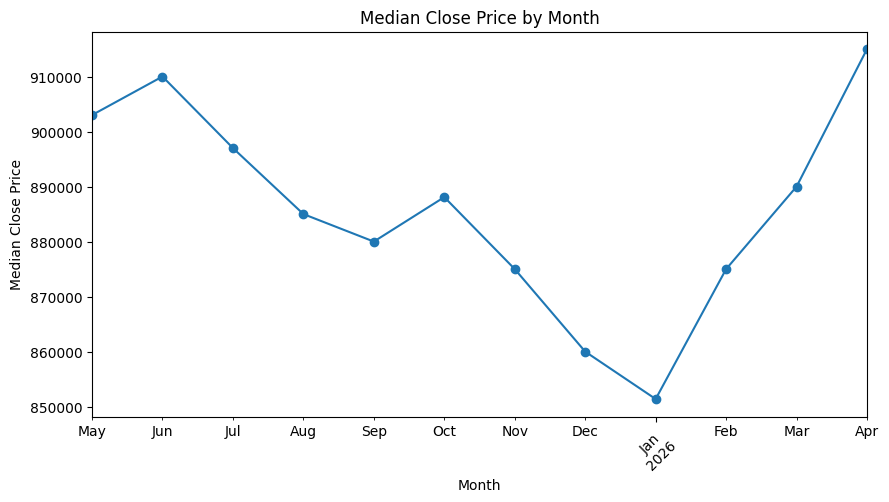

In [60]:
filtered_df["CloseMonth"] = (
    filtered_df["CloseDate"].dt.to_period("M")
)

monthly_prices = filtered_df.groupby(
    "CloseMonth"
)["ClosePrice"].median()

monthly_prices.plot(
    marker="o",
    figsize=(10, 5)
)

plt.title("Median Close Price by Month")
plt.xlabel("Month")
plt.ylabel("Median Close Price")
plt.xticks(rotation=45)
plt.show()